Data analysis on diabetes-related medical information

### Important: this is a synthetic dataset. It is intended to mimick patterns found in a real dataset, but the datapoints do not represent real patients

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

In [81]:
path = kagglehub.dataset_download(
    "mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients"
)

print("Dataset downloaded to:", path)
print("Files:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))


Dataset downloaded to: C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1
Files:
C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1\diabetes_risk_prediction_dataset.csv


Gathering data profile 

In [82]:
display(diabetes_df)

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,#_diseases
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,4
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,5
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,3
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,3
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,52.0,Female,United Kingdom,153.9,107.4,45.3,75.9,248.8,9.9,...,Yes,Average,Retired,Urban,3.5,86,Consult Endocrinologist Immediately,Yes,High,3
49996,49997,53.0,Male,United Kingdom,179.6,64.0,19.8,114.5,198.4,6.3,...,No,Average,Government,Urban,3.4,49,Weight Management Program,No,Moderate,2
49997,49998,88.0,Male,Brazil,194.1,65.6,17.4,96.1,118.8,NaN,...,Yes,Poor,Retired,Urban,2.6,100,Begin Diabetes Management Plan,Yes,High,5
49998,49999,23.0,Other,Bangladesh,168.0,73.9,26.2,131.4,139.5,9.2,...,Yes,Good,Private,Urban,2.7,52,Increase Physical Activity,No,Moderate,2


In [83]:
diabetes_data = pd.read_csv(r"C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1\diabetes_risk_prediction_dataset.csv")
diabetes_df = pd.DataFrame(diabetes_data)
ini_N_rows = diabetes_df.shape[0]
#print(diabetes_df.head())
print("---------")
print(diabetes_df.info())
print("---------")
print(diabetes_df.shape)

---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diasto

In [96]:
diabetes_df.describe().round()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score,#_diseases
count,48557.0,48557.0,45703.0,45669.0,48557.0,48557.0,48557.0,46636.0,48557.0,48557.0,...,47581.0,47583.0,47586.0,48557.0,46618.0,46646.0,46591.0,48557.0,48557.0,48557.0
mean,24988.0,54.0,170.0,87.0,31.0,100.0,160.0,8.0,143.0,23.0,...,57.0,135.0,229.0,85.0,5.0,90.0,7.0,3.0,74.0,3.0
std,14437.0,21.0,14.0,25.0,10.0,23.0,52.0,2.0,45.0,12.0,...,19.0,49.0,98.0,20.0,3.0,52.0,2.0,1.0,16.0,1.0
min,1.0,18.0,145.0,45.0,12.0,60.0,70.0,4.0,65.0,2.0,...,25.0,50.0,60.0,50.0,0.0,0.0,3.0,1.0,13.0,0.0
25%,12475.0,35.0,158.0,66.0,23.0,80.0,115.0,6.0,104.0,13.0,...,41.0,92.0,144.0,68.0,2.0,45.0,5.0,2.0,64.0,3.0
50%,24974.0,54.0,170.0,87.0,30.0,100.0,160.0,8.0,143.0,23.0,...,57.0,135.0,230.0,85.0,5.0,90.0,6.0,3.0,75.0,3.0
75%,37499.0,72.0,183.0,108.0,38.0,120.0,205.0,10.0,182.0,34.0,...,74.0,178.0,314.0,103.0,8.0,135.0,8.0,4.0,86.0,4.0
max,50000.0,90.0,195.0,130.0,62.0,140.0,250.0,12.0,220.0,45.0,...,90.0,220.0,400.0,120.0,10.0,180.0,10.0,5.0,100.0,6.0


Data cleaning

In [84]:
print(f"Missing values: {diabetes_df.isnull().sum()}")

Missing values: Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Fami

In [85]:
#Make missing values uniform in format
diabetes_df = diabetes_df.replace("",pd.NA)

#exclude columsn where more than 1/10th of all rows are empty, 
#for possible future changes in the data
column_cutoff = diabetes_df.shape[0]/10
print(column_cutoff)
diabetes_df = diabetes_df.dropna(axis = 1, thresh=column_cutoff)
print(diabetes_df.shape)

5000.0
(50000, 41)


In [86]:

#Drop rows with age missing. Too basic of an indicator to miss and makes up only a small % of datapoints. 
#Missing age can be nothing else than data integrity issues
#No significant bias expected in why some datapoints have no registered age.
diabetes_df= diabetes_df. dropna(axis=0, subset=['Age'])
print(diabetes_df.shape)
#Same reasoning for glucose level, with the comment that absence of this information
#might be an indicator for subpar healthcare or on the other hand, no noticable health issues to warrant 
#medical research. Significant bias not probable, but possible
#the presence of the insulin levels and fasting blood sugar will lessen any such impact
diabetes_df= diabetes_df. dropna(axis=0, subset=['Blood_Glucose'])
print(diabetes_df.shape)

current_nrows = diabetes_df.shape[0]
filteredrows = round(current_nrows/ini_N_rows *100)
print(f"Datapoints left: {filteredrows}%")

(49503, 41)
(48557, 41)
Datapoints left: 97%


Data exploration

In [87]:
#General data profile overview; discrete values
print(diabetes_df.value_counts("Gender"))
print(diabetes_df.value_counts("Country"))
print(diabetes_df.value_counts("Fatty_Liver"))
print(diabetes_df.value_counts("PCOS"))
print(diabetes_df.value_counts("Medication_Adherence"))
print(diabetes_df.value_counts("Work_Type"))
print(diabetes_df.value_counts("Residence_Type"))
print(diabetes_df.value_counts("AI_Health_Recommendation"))
print(diabetes_df.value_counts("Doctor_Consultation_Needed"))
print(diabetes_df.value_counts("Diabetes_Risk"))
print(diabetes_df.value_counts("Diet_Quality"))
print(diabetes_df.value_counts("Stress_Level"))
print(diabetes_df.value_counts("Alcohol_Consumption"))
print(diabetes_df.value_counts("Family_History_Diabetes"))
print(diabetes_df.value_counts("Hypertension"))
print(diabetes_df.value_counts("Heart_Disease"))
print(diabetes_df.value_counts("Smoking_Status"))

Gender
Male      16258
Other     16163
Female    16136
Name: count, dtype: int64
Country
Malaysia          2041
France            2014
China             2011
Russia            2008
Canada            1994
United Kingdom    1985
Nigeria           1969
Egypt             1957
Mexico            1952
Indonesia         1949
South Korea       1941
Italy             1940
Spain             1938
Turkey            1931
Germany           1929
South Africa      1921
India             1920
Brazil            1919
Japan             1918
Bangladesh        1914
Argentina         1901
Pakistan          1899
Australia         1897
United States     1879
Saudi Arabia      1830
Name: count, dtype: int64
Fatty_Liver
No     24404
Yes    24153
Name: count, dtype: int64
PCOS
No     24348
Yes    24209
Name: count, dtype: int64
Medication_Adherence
Good       15894
Average    15875
Poor       15823
Name: count, dtype: int64
Work_Type
Business      9871
Private       9784
Government    9708
Student       9666
Retir

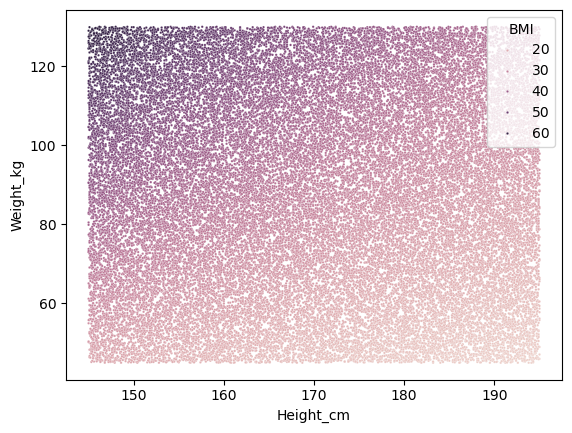

In [88]:

#plot correlation height,weight, bmi
sns.scatterplot(diabetes_df, x = 'Height_cm', y= 'Weight_kg', hue='BMI', s=3)
plt.show()
#Data integrity; Calcuation of BMI validated
#No apparent clusters of height/weight combinations in overall data

#Possibility to explore, using bmi as stand-in for weight and height. 
#Investigate if height has no inherent influence on diabetes risk
#Or if absolute weight has more impact than BMI

<bound method NDFrame.head of        Patient_ID   Age  Gender         Country  Height_cm  Weight_kg   BMI  \
0               1  32.0    Male          Mexico      182.1       65.8  19.8   
1               2  42.0   Other    Saudi Arabia      148.5      101.2  45.9   
2               3  89.0   Other       Argentina      158.1        NaN  37.9   
3               4  87.0   Other   United States      190.9       95.9  26.3   
4               5  27.0   Other       Australia      156.9      101.9  41.4   
...           ...   ...     ...             ...        ...        ...   ...   
49995       49996  52.0  Female  United Kingdom      153.9      107.4  45.3   
49996       49997  53.0    Male  United Kingdom      179.6       64.0  19.8   
49997       49998  88.0    Male          Brazil      194.1       65.6  17.4   
49998       49999  23.0   Other      Bangladesh      168.0       73.9  26.2   
49999       50000  24.0  Female       Australia      152.8       94.6  40.5   

       Waist_Circumfe

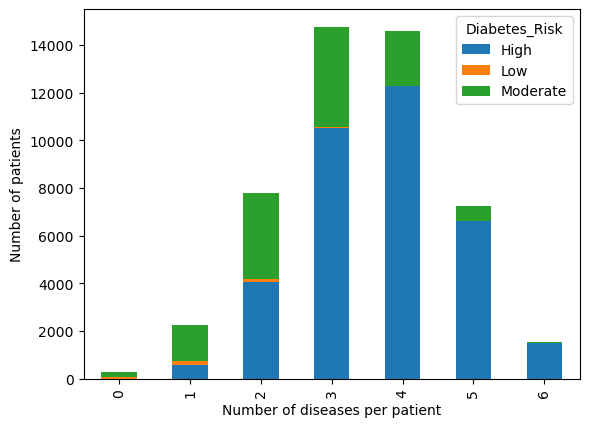

In [89]:
#count the "Yes" per row, giving an overview of number of recorded health issues per patient
diabetes_df['#_diseases'] = diabetes_df.eq("Yes").sum(axis=1)
print(diabetes_df.head)
#distribution of #diseases

datastack_DR_NumD = pd.crosstab(diabetes_df['#_diseases'],
 diabetes_df['Diabetes_Risk'])
datastack_DR_NumD.plot(kind='bar',stacked=True)
plt.xlabel("Number of diseases per patient")
plt.ylabel("Number of patients")
plt.show()

#Conclusion, # of diseases seems strongly correlated to diabetes risk

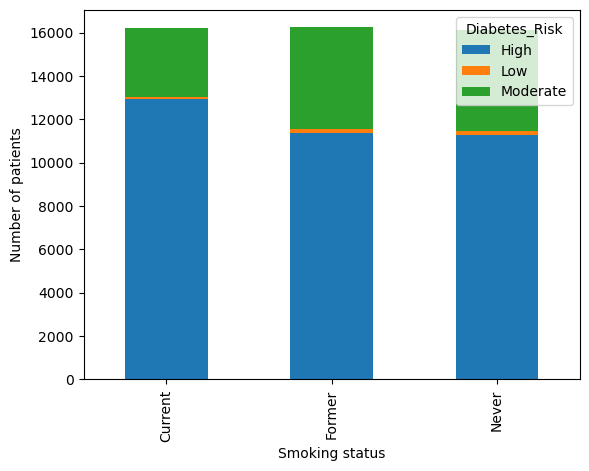

In [93]:
datastack_DR_NumD = pd.crosstab(diabetes_df['Smoking_Status'],
 diabetes_df['Diabetes_Risk'])
datastack_DR_NumD.plot(kind='bar',stacked=True)
plt.xlabel("Smoking status")
plt.ylabel("Number of patients")
plt.show()


In [91]:
#import machine learning tools
from sklearn.model_selection import train_test_split 

In [92]:
#Feature selection


target = diabetes_df['Diabetes_Risk']
features = diabetes_df.drop(columns=['Diabetes_Risk'])
print(f"Number_of_features: {features.shape[1]}")
print(features.columns)


Number_of_features: 41
Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg',
       'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c',
       'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL',
       'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality',
       'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence',
       'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L',
       'Diabetes_Risk_Score', 'AI_Health_Recommendation',
       'Doctor_Consultation_Needed', '#_diseases'],
      dtype='object')
